# Tarea 2 De Procesamiento de Imagenes

El siguiente codigo tiene fragmentos de codigo sacado de la siguiente fuente citada:

Ignacio Vicente Marambio Zamora. 2025. *Tarea 1* [Codigo Fuente](https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672). UDP Canvas Tarea 1. [https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672](https://udp.instructure.com/courses/35900/assignments/296061/submissions/3166?download=4608672).

mlacarrasco. 2025. *23_filtro_mediana.py* [Codigo Fuente](https://github.com/mlacarrasco/image_processing/blob/main/23_filtro_mediana.py). Github image_processing. [https://github.com/mlacarrasco/image_processing/blob/main/23_filtro_mediana.py](https://github.com/mlacarrasco/image_processing/blob/main/23_filtro_mediana.py).

mlacarrasco. 2025. *11_binarizacion.py* [Codigo Fuente](https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py). Github image_processing. [https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py](https://github.com/mlacarrasco/image_processing/blob/main/11_binarizacion.py).

## Programa Solicitado

Desarrolle un programa en Python que cumpla los siguientes requerimientos:
1. Utilice la imagen de soldadura que se encuentra en la intranet (adjunta con la tarea)
2. Genere una nueva imagen ecualizada y comente los resultados respecto a la imagen original.
3. Genere una imagen “libre de ruido” 1 empleando el filtro de la mediana con la imagen obtenida en paso-2. Busque un valor óptimo que atenúe completamente las fallas empleando el filtro de la mediana. Una vez definido un determinado valor, utilícelo en los siguientes pasos (Importante:el tamaño de máscara debe ser impar, ver Hint).
4. Reste la imagen del paso-3 con la del paso-2 y despliegue el resultado por el browser (en colab). Analice en qué casos las fallas son más visibles según el parámetro del paso-3 y comente sus resultados. Solo las fallas debieran ser visibles como resultado de este paso.
5. Binarice la imagen del paso 4 empleando una operación lógica según un umbral que usted defina. El objetivo de la binarización es que las fallas queden reflejadas en color blanco (valor 1), y el fondo en color negro (valor 0).
6. Finalmente multiplique punto a punto la imagen binaria del paso-5 con la imagen del paso-2 de tal modo que sólo sean visibles los niveles de intensidad de las fallas (en escala de grises), y el fondo se vea en color negro.

### Descripción de lo que hace:
Éste programa tiene como finalidad aislar algunas grietas de una foto asociada a una soldadura.
Para eso se usó una variedad de filtros tales como el filtro de mediana *(median blur)*, normalización y operaciones aritmeticas de distinto tipo en las imagenes procesadas.

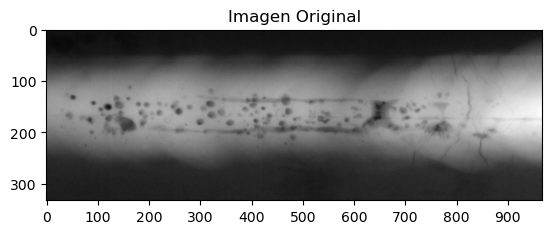

In [4]:
# Paso 1: Cargar la imagen
import cv2
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.image as mpimg

# Cargar la imagen 'fallas.tif'
filename = 'fallas.tif'

def loadimage(filename):
    img = cv2.imread(filename)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    return gray

def showimage(img, title=''):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('on')
    # Mostrar ticks cada 10 bits en los ejes x e y
    plt.xticks(np.arange(0, img.shape[1], 100))
    plt.yticks(np.arange(0, img.shape[0], 100))
    plt.show()

showimage(loadimage(filename), 'Imagen Original')

En la imagen se pueden ver a simple vista los puntos de soldadura, así como las grietas de la misma que demuestran la falla del material.
El objetivo final es aislar y poder observar con mayor claridad las imperfecciones de la soldadura.

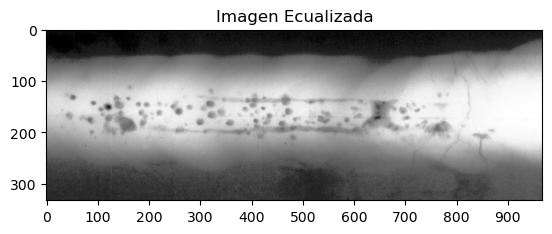

In [5]:
# Paso 2: Crear imagen ecualizada.

equalized_image = cv2.equalizeHist(loadimage(filename))
showimage(equalized_image, 'Imagen Ecualizada')


Aplicar normalización a la imagen permite ver con mayor claridad el espectro completo de la imagen viendo así el material de forma más nitida, como sus puntos e imperfecciones.

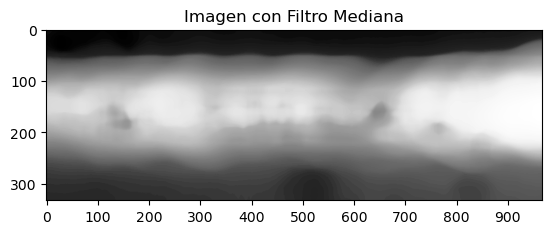

In [6]:
# Paso 3: Emplera filtro mediana.
imagen_mediana = cv2.medianBlur(equalized_image, 39)
showimage(imagen_mediana, 'Imagen con Filtro Mediana')

Aplicar este filtro permite difuminar las marcas, creando un fondo con imperfecciones reducidas.
Esto será particularmente útil para hacer la diferencia con las marcas tal y como se ve en la imagen siguiente:

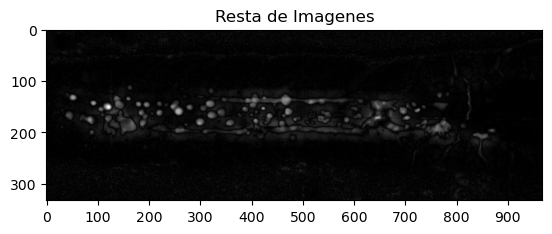

In [7]:
# Paso 4: Restar imagen Paso 3 - Paso 2
resta = cv2.absdiff(equalized_image, imagen_mediana)
showimage(resta, 'Resta de Imagenes')

Notese que la diferencia absoluta entre las dos ultimas imagenes permite obtener las marcas de la soldadura con mayor claridad.
No obstante si lo que se busca es una imagen perfecta de dichas marcas, hay que hacer que aquellos puntos blancos se vean mientras lo demás desaparece.
Un filtro de binrarización viene bien para el caso tal como se muestra en el codigo siguiente.

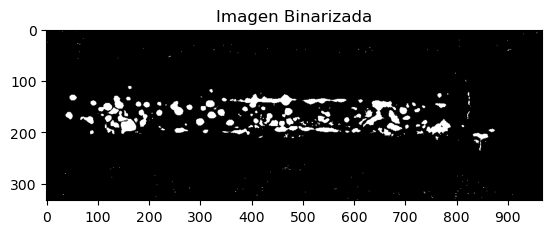

In [8]:
#Paso 5: Aplicar Filtro Binarizacion
#5.1 Obtener proporciones de la imagen

#Nomralizar la imagen
resta = cv2.normalize(resta, None, 0, 255, cv2.NORM_MINMAX)

_,threshold = cv2.threshold(resta,35.5,255,cv2.THRESH_BINARY)
#5.2 Aplicar filtro binarizacion
showimage(threshold, 'Imagen Binarizada')



In [ ]:
Como punto final a la reperesentacion de la imagen, se realiza una multiplicacion de la imagen binarizada por la imagen original, para obtener una imagen que contenga las fallas.
Esto nos muestra con total claridad las fallas en la imagen original.


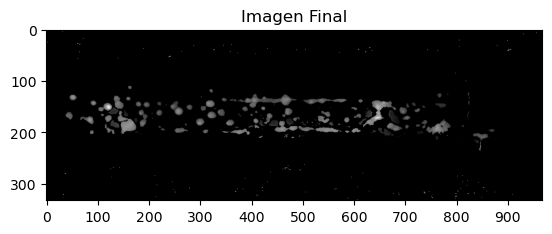

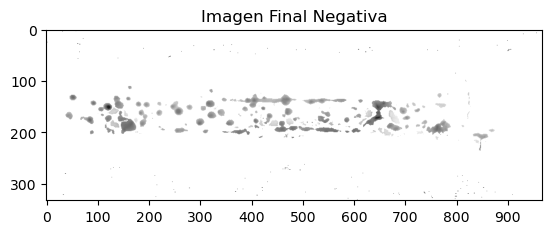

In [10]:
# Paso 6
result = np.multiply(threshold,equalized_image)
showimage(result, 'Imagen Final')
# Aplicar negativo a la imagen final
negative_result = cv2.bitwise_not(result)
showimage(negative_result, 'Imagen Final Negativa')




# Conclusión
A modo de resumen se puede decir que a partir de la imagen original se puede obtener una imagen con las imperfecciones de la soldadura, y que al aplicar un filtro de binarización se pueden ver con mayor claridad.
El metodo pars hacer esto consistio en separar la imagen en dos partes, una con las imperfecciones y otra con el fondo.
Para hacer esto se usaron filtros de mediana y normalización, así como operaciones aritmeticas entre las imagenes.
